# Classification Metrics

In [19]:
import pandas as pd
blood_transfusion = pd.read_csv('data/blood_transfusion.csv')
data = blood_transfusion.drop(columns="Class")
target = blood_transfusion["Class"]

In [20]:
data.head()

,Recency,Frequency,Monetary,Time
0,2,50,12500,98
1,0,13,3250,28
2,1,16,4000,35
3,2,20,5000,45
4,1,24,6000,77


In [21]:
target.head()

0        donated
1        donated
2        donated
3        donated
4    not donated
Name: Class, dtype: object

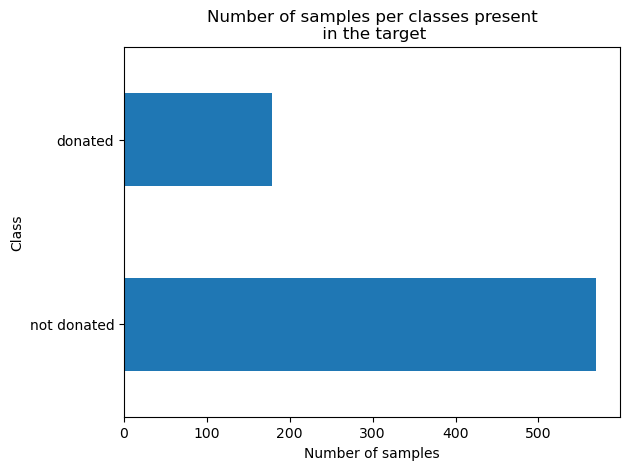

In [22]:
import matplotlib.pyplot as plt

target.value_counts().plot.barh()
plt.xlabel("Number of samples")
_ = plt.title("Number of samples per classes present\n in the target")

In [23]:
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test = train_test_split(
    data, target, shuffle=True, random_state=0, test_size=0.5
)

In [24]:
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression()
classifier.fit(data_train, target_train)

LogisticRegression()

In [25]:
new_donor = pd.DataFrame(
    {
        "Recency": [6],
        "Frequency": [2],
        "Monetary": [1000],
        "Time": [20],
    }
)

In [26]:
classifier.predict(new_donor)

array(['not donated'], dtype=object)

In [27]:
target_predicted = classifier.predict(data_test)
target_predicted[:5]

array(['not donated', 'not donated', 'not donated', 'not donated',
       'donated'], dtype=object)

In [28]:
target_test == target_predicted

258     True
521    False
14     False
31     False
505     True
       ...  
665     True
100    False
422     True
615     True
743     True
Name: Class, Length: 374, dtype: bool

> Accuracy
- Accuracy is an aggregate of the errors made by the classifier


In [29]:
import numpy as np

np.mean(target_test == target_predicted) # accuracy

0.7780748663101604

In [30]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(target_test, target_predicted)
print(f"Accuracy: {accuracy:.3f}")

Accuracy: 0.778


In [31]:
classifier.score(data_test, target_test)

0.7780748663101604

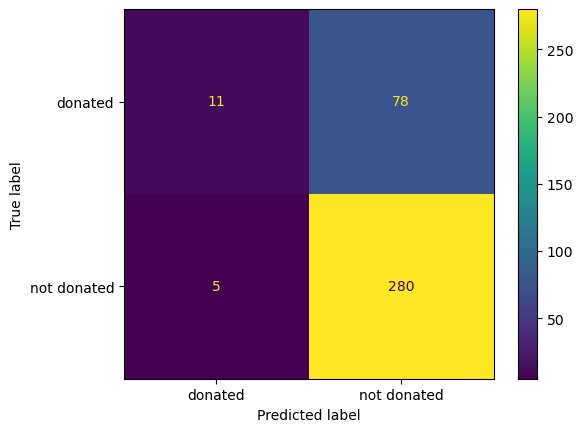

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay

_ = ConfusionMatrixDisplay.from_estimator(classifier, data_test, target_test)

The in-diagonal numbers are related to predictions that were correct while off-diagonal numbers are related to incorrect predictions (misclassifications). We now know the four types of correct and erroneous predictions:

- the top left corner are true positives (TP) and corresponds to people who gave blood and were predicted as such by the classifier;
- the bottom right corner are true negatives (TN) and correspond to people who did not give blood and were predicted as such by the classifier;
- the top right corner are false negatives (FN) and correspond to people who gave blood but were predicted to not have given blood;
- the bottom left corner are false positives (FP) and correspond to people who did not give blood but were predicted to have given blood.

- ****precision :**** is defined as TP / (TP + FP) and represents how likely the person actually gave blood when the classifier predicted that they did. 

- ****recall :**** is defined as TP / (TP + FN) and assesses how well the classifier is able to correctly identify people who did give blood. 

In [33]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(target_test, target_predicted, pos_label="donated")
recall = recall_score(target_test, target_predicted, pos_label="donated")

print(f"Precision score: {precision:.3f}")
print(f"Recall score: {recall:.3f}")

Precision score: 0.688
Recall score: 0.124


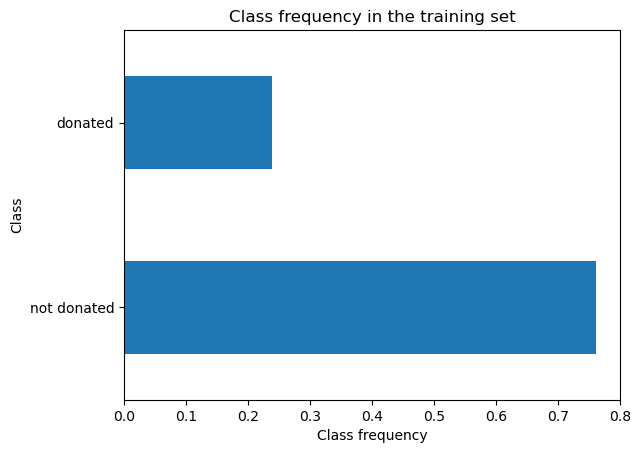

In [34]:
target_train.value_counts(normalize=True).plot.barh()
plt.xlabel("Class frequency")
_ = plt.title("Class frequency in the training set")

- the positive class, 'donated', comprises only 24% of the samples. The good accuracy of our classifier is then linked to its ability to correctly predict the negative class 'not donated'

In [18]:
from sklearn.dummy import DummyClassifier

dummy_classifier = DummyClassifier(strategy="most_frequent")
dummy_classifier.fit(data_train, target_train)
print(
    "Accuracy of the dummy classifier: "
    f"{dummy_classifier.score(data_test, target_test):.3f}"
)

Accuracy of the dummy classifier: 0.762


- The problem illustrated above is also known as the class imbalance problem. When the classes are imbalanced, accuracy should not be used. In this case, one should either use the precision and recall as presented above or the balanced accuracy score instead of accuracy.

In [35]:
from sklearn.metrics import balanced_accuracy_score

balanced_accuracy = balanced_accuracy_score(target_test, target_predicted)
print(f"Balanced accuracy: {balanced_accuracy:.3f}")

Balanced accuracy: 0.553


---

In [36]:
target_proba_predicted = pd.DataFrame(
    classifier.predict_proba(data_test), columns=classifier.classes_
)
target_proba_predicted[:5]

,donated,not donated
0,0.271818,0.728182
1,0.451765,0.548235
2,0.445210,0.554790
3,0.441577,0.558423
4,0.870588,0.129412


In [37]:
target_predicted = classifier.predict(data_test)
target_predicted[:5]

array(['not donated', 'not donated', 'not donated', 'not donated',
       'donated'], dtype=object)

In [38]:
equivalence_pred_proba = (
    target_proba_predicted.idxmax(axis=1).to_numpy() == target_predicted
)
np.all(equivalence_pred_proba)

True

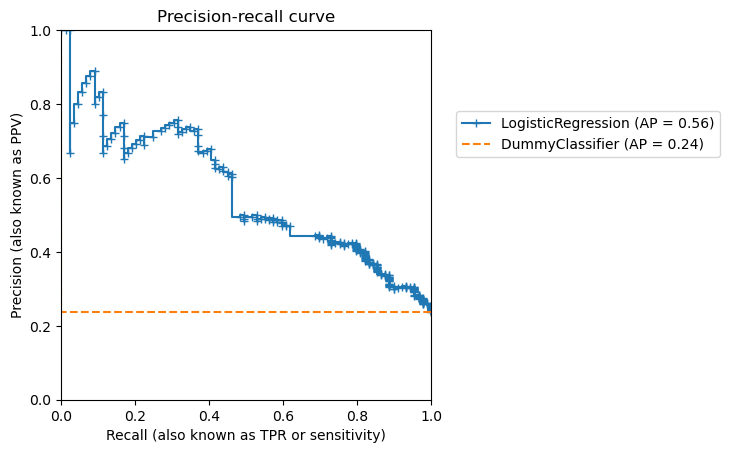

In [39]:
from sklearn.metrics import PrecisionRecallDisplay

disp = PrecisionRecallDisplay.from_estimator(
    classifier, data_test, target_test, pos_label="donated", marker="+"
)
disp = PrecisionRecallDisplay.from_estimator(
    dummy_classifier,
    data_test,
    target_test,
    pos_label="donated",
    color="tab:orange",
    linestyle="--",
    ax=disp.ax_,
)
plt.xlabel("Recall (also known as TPR or sensitivity)")
plt.ylabel("Precision (also known as PPV)")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
_ = disp.ax_.set_title("Precision-recall curve")

In [40]:
prevalence = target_test.value_counts()[1] / target_test.value_counts().sum()
print(f"Prevalence of the class 'donated': {prevalence:.2f}")

Prevalence of the class 'donated': 0.24


C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_10556\2781295333.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  prevalence = target_test.value_counts()[1] / target_test.value_counts().sum()


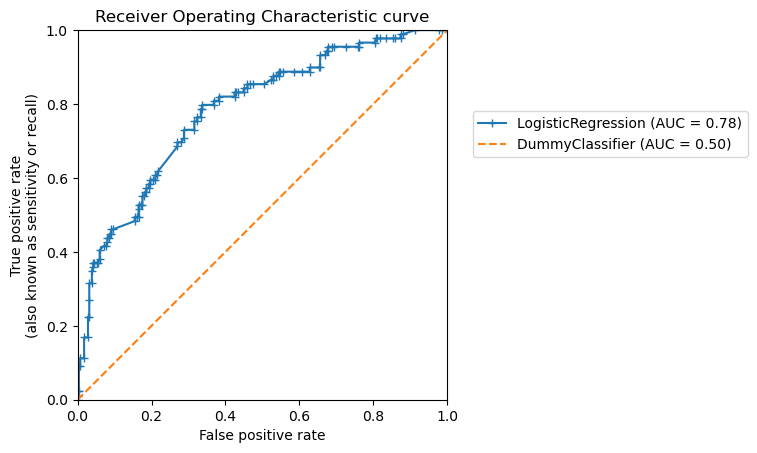

In [41]:
from sklearn.metrics import RocCurveDisplay

disp = RocCurveDisplay.from_estimator(
    classifier, data_test, target_test, pos_label="donated", marker="+"
)
disp = RocCurveDisplay.from_estimator(
    dummy_classifier,
    data_test,
    target_test,
    pos_label="donated",
    color="tab:orange",
    linestyle="--",
    ax=disp.ax_,
)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate\n(also known as sensitivity or recall)")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
_ = disp.ax_.set_title("Receiver Operating Characteristic curve")

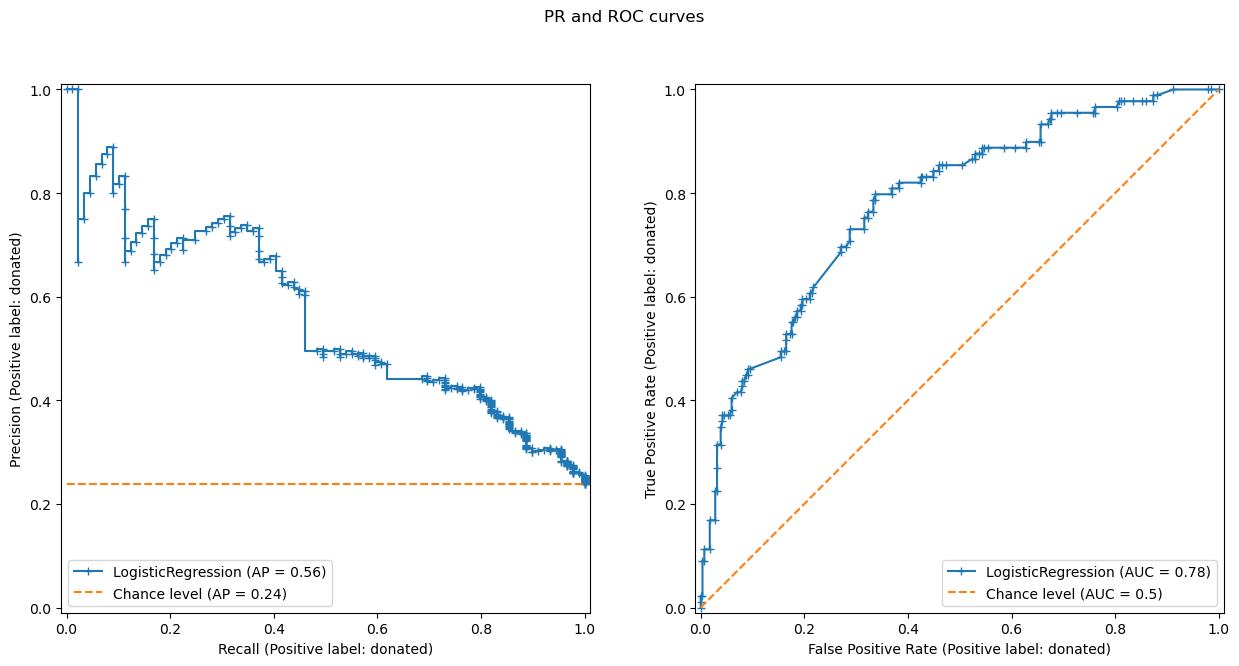

In [42]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(15, 7))

PrecisionRecallDisplay.from_estimator(
    classifier,
    data_test,
    target_test,
    pos_label="donated",
    marker="+",
    plot_chance_level=True,
    chance_level_kw={"color": "tab:orange", "linestyle": "--"},
    ax=axs[0],
)
RocCurveDisplay.from_estimator(
    classifier,
    data_test,
    target_test,
    pos_label="donated",
    marker="+",
    plot_chance_level=True,
    chance_level_kw={"color": "tab:orange", "linestyle": "--"},
    ax=axs[1],
)

_ = fig.suptitle("PR and ROC curves")